In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

In [ ]:
df = pd.read_csv("energy_dataset-2.csv")

df = df.dropna(axis=1, how='all')

if 'time' in df.columns:
    df['time'] = pd.to_datetime(df['time'], utc=True)

if 'price day ahead' in df.columns:
    df['price day ahead'] = pd.to_numeric(df['price day ahead'], errors='coerce')

df = df.ffill()

print(f"Dataset successfully loaded and cleaned. Total rows: {len(df)}")
print("Columns found:", df.columns.tolist())

Dataset successfully loaded and cleaned. Total rows: 35064
Columns found: ['time', 'generation biomass', 'generation fossil brown coal/lignite', 'generation fossil coal-derived gas', 'generation fossil gas', 'generation fossil hard coal', 'generation fossil oil', 'generation fossil oil shale', 'generation fossil peat', 'generation geothermal', 'generation hydro pumped storage consumption', 'generation hydro run-of-river and poundage', 'generation hydro water reservoir', 'generation marine', 'generation nuclear', 'generation other', 'generation other renewable', 'generation solar', 'generation waste', 'generation wind offshore', 'generation wind onshore', 'forecast solar day ahead', 'forecast wind onshore day ahead', 'total load forecast', 'total load actual', 'price day ahead', 'price actual']


In [ ]:
df['Hour'] = df['time'].dt.hour
df['Day'] = df['time'].dt.day_name()

renewable_cols = [
    'generation solar', 'generation wind onshore', 'generation wind offshore',
    'generation hydro run-of-river and poundage', 'generation hydro water reservoir',
    'generation biomass', 'generation geothermal'
]

fossil_cols = [
    'generation fossil brown coal/lignite', 'generation fossil gas',
    'generation fossil hard coal', 'generation fossil oil',
    'generation fossil coal-derived gas'
]

df['Total_Renewable'] = df[[c for c in renewable_cols if c in df.columns]].sum(axis=1)
df['Total_Fossil'] = df[[c for c in fossil_cols if c in df.columns]].sum(axis=1)

df[['time', 'Hour', 'Total_Renewable', 'Total_Fossil', 'price actual']].head()

,time,Hour,Total_Renewable,Total_Fossil,price actual
0,2014-12-31 23:00:00+00:00,23,9824.0,10156.0,65.41
1,2015-01-01 00:00:00+00:00,0,9056.0,10437.0,64.92
2,2015-01-01 01:00:00+00:00,1,8303.0,9918.0,64.48
3,2015-01-01 02:00:00+00:00,2,7454.0,8859.0,59.32
4,2015-01-01 03:00:00+00:00,3,7078.0,8313.0,56.04


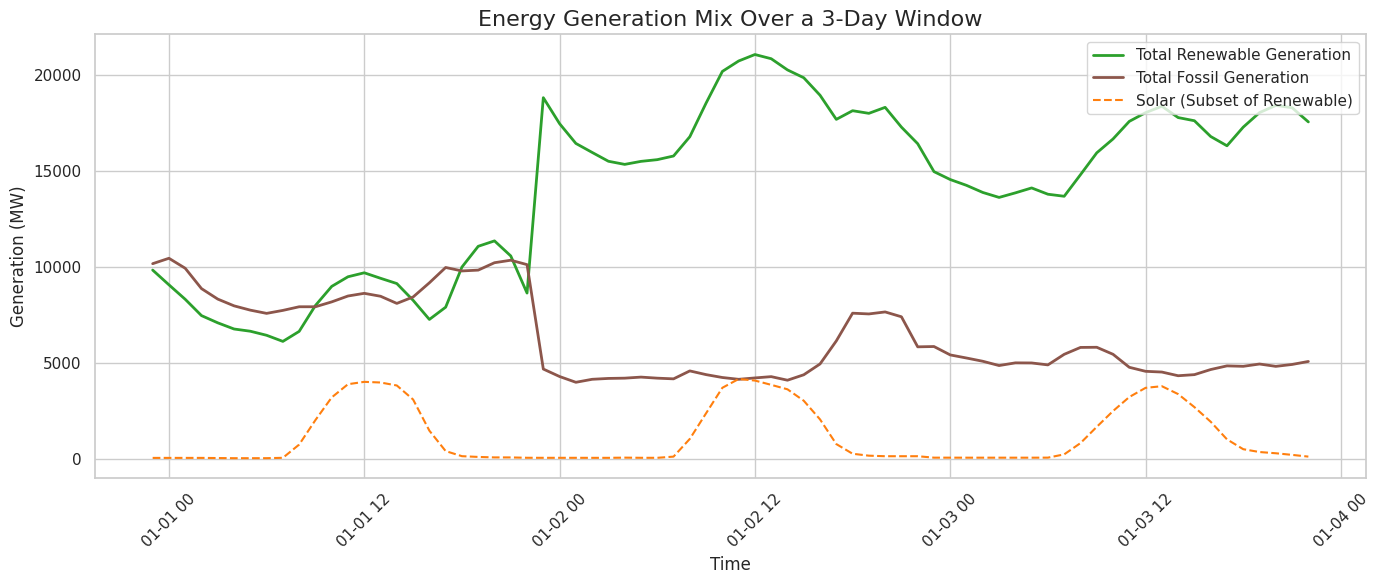

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(df['time'][:72], df['Total_Renewable'][:72], label='Total Renewable Generation', color='#2ca02c', linewidth=2)
plt.plot(df['time'][:72], df['Total_Fossil'][:72], label='Total Fossil Generation', color='#8c564b', linewidth=2)

if 'generation solar' in df.columns:
    plt.plot(df['time'][:72], df['generation solar'][:72], label='Solar (Subset of Renewable)', color='#ff7f0e', linestyle='--')

plt.title('Energy Generation Mix Over a 3-Day Window', fontsize=16)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Generation (MW)', fontsize=12)
plt.legend(loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

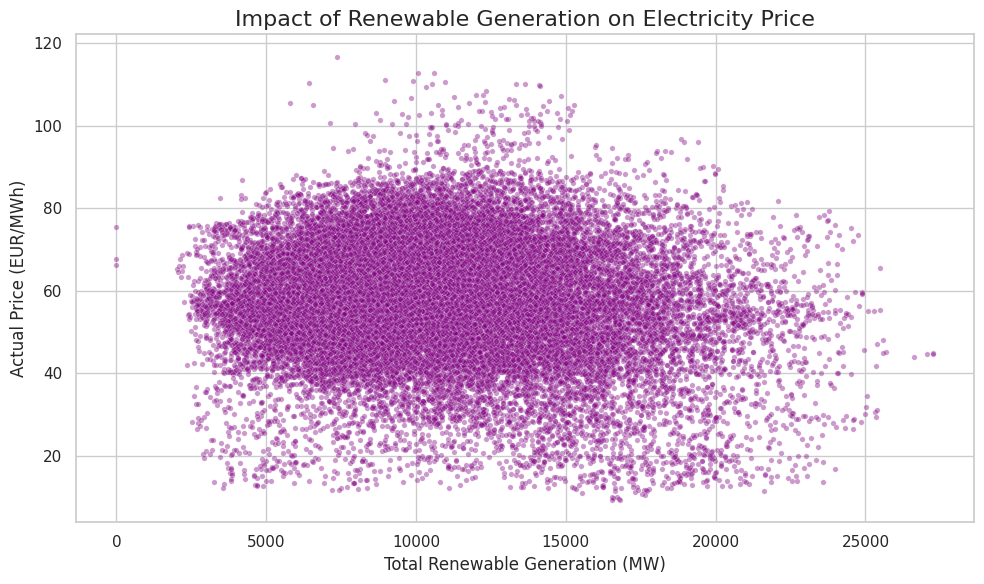

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='Total_Renewable', y='price actual', alpha=0.4, color='purple', s=15)

plt.title('Impact of Renewable Generation on Electricity Price', fontsize=16)
plt.xlabel('Total Renewable Generation (MW)', fontsize=12)
plt.ylabel('Actual Price (EUR/MWh)', fontsize=12)
plt.tight_layout()
plt.show()

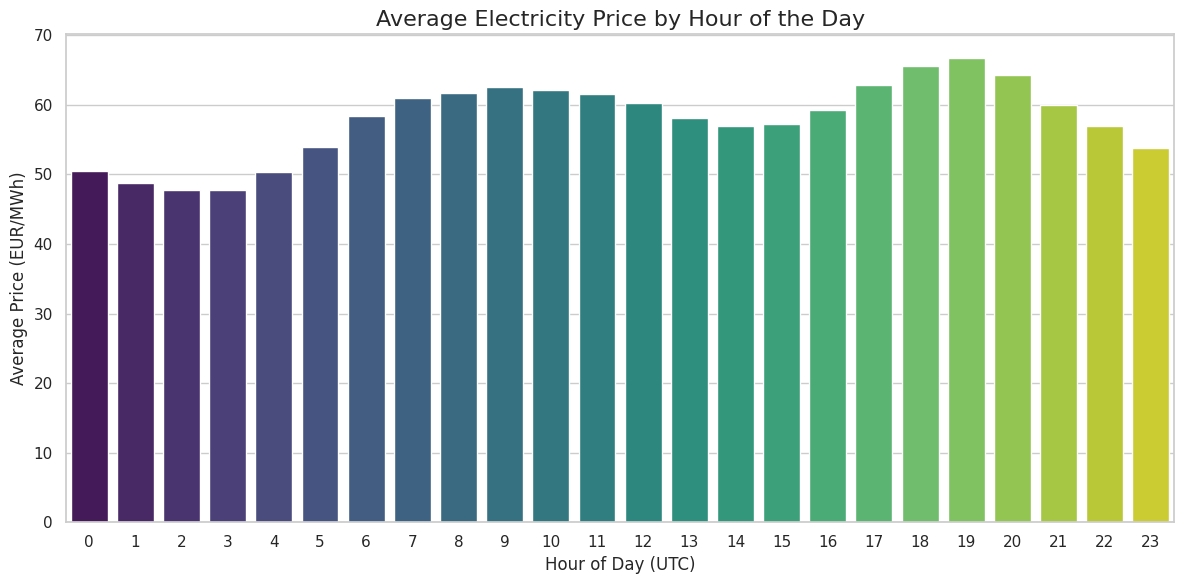

In [ ]:
hourly_price = df.groupby('Hour')['price actual'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=hourly_price, x='Hour', y='price actual', palette='viridis')

plt.title('Average Electricity Price by Hour of the Day', fontsize=16)
plt.xlabel('Hour of Day (UTC)', fontsize=12)
plt.ylabel('Average Price (EUR/MWh)', fontsize=12)
plt.tight_layout()
plt.show()